<a href="https://colab.research.google.com/github/Levi-Cavalcantech/testes-python/blob/main/Projeto_Grafos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://github.com/shellfly/algs4-py/archive/refs/heads/master.zip
!unzip master.zip
print("Importação funcionou")

In [ ]:
!pip install powerlaw

import sys
sys.path.insert(0, '/content/algs4-py-master')

import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

from algs4.digraph import Digraph

In [ ]:
url = "https://snap.stanford.edu/data/web-Stanford.txt.gz"
urllib.request.urlretrieve(url, "web-Stanford.txt.gz")

edges = [] #arestas
max_node = 0 #maximo de nos

with gzip.open("web-Stanford.txt.gz", "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        u, v = map(int, line.split())
        edges.append((u, v))
        max_node = max(max_node, u, v) #maximo de nós

n = max_node + 1 #total de nós

G = Digraph(n) #criação do grafo
for u, v in edges:
    G.add_edge(u, v) #montagem do grafo

print("Grafo carregado")

Grafo carregado


In [ ]:
indegree = [0] * n #instancia de entrada
outdegree = [0] * n #instancia de saida

for v in range(n):  #pecorre todos os vertices
    for w in G.adj[v]: #percorre os vertice ligados a v
        outdegree[v] += 1 # incrementa os as arestas de saida
        indegree[w] += 1 # incrementa os as arestas de saida

degrees = np.array([indegree[v] + outdegree[v] for v in range(n)]) #grau total

m = len(edges)

print("=== Estatísticas Iniciais ===")
print(f"Número de nós: {n}")
print(f"Número de arestas: {m}")
print(f"Grau médio: {degrees.mean():.2f}")
print(f"Grau mínimo: {degrees.min()}")
print(f"Grau máximo: {degrees.max()}")

density = m / (n * (n - 1))
print(f"Densidade: {density:.6f}")

=== Estatísticas Iniciais ===
Número de nós: 281904
Número de arestas: 2312497
Grau médio: 16.41
Grau mínimo: 0
Grau máximo: 38626
Densidade: 0.000029


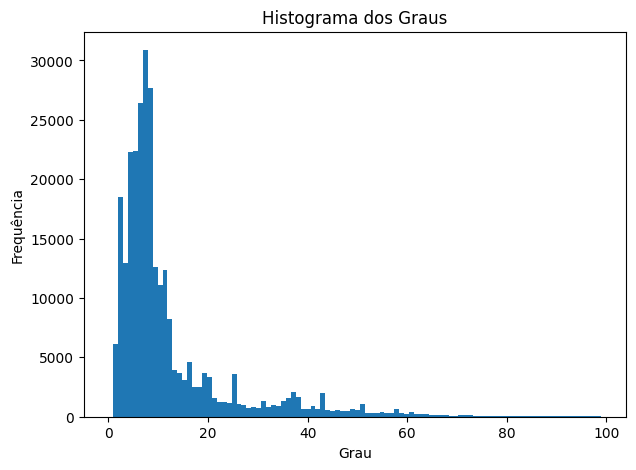

In [ ]:
plt.figure(figsize=(7,5)) #quantos n´s para cada grau
plt.hist([d for d in degrees if d < 100], bins=100)
plt.title("Histograma dos Graus")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()

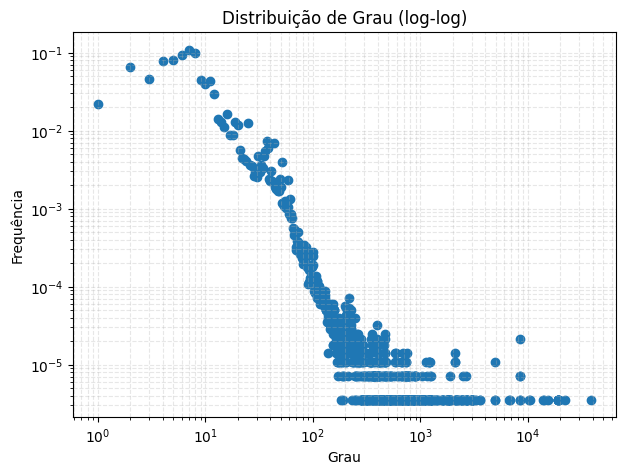

In [ ]:
degree_count = np.bincount(degrees) #Nós com grau
deg = np.nonzero(degree_count)[0] #indices onde são maior que 0
freq = degree_count[deg] / sum(degree_count) #probabilidade

plt.figure(figsize=(7,5))
plt.scatter(deg, freq)
plt.xscale("log")
plt.yscale("log")
plt.title("Distribuição de Grau (log-log)")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/powerlaw/fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 733/733 [00:12<00:00, 60.83it/s] 


Alpha: 2.12203622477709
xmin: 113.0
Ângulo da reta (graus): -64.76805375205352


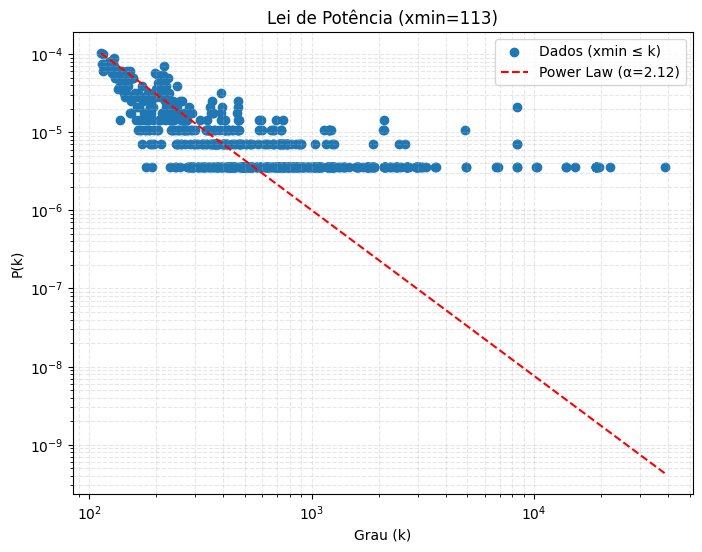

In [ ]:
fit = powerlaw.Fit(degrees, discrete=True) # função de estimativa
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

slope_powerlaw = -alpha
angle_rad = np.arctan(slope_powerlaw)
angle_deg = np.degrees(angle_rad)

print("Alpha:", alpha)
print("xmin:", xmin)
print("Ângulo da reta (graus):", angle_deg)

degree_count = np.bincount(degrees)
deg = np.nonzero(degree_count)[0]
freq = degree_count[deg] / sum(degree_count)

mask = (deg >= xmin)

deg_cut = deg[mask]
freq_cut = freq[mask]

x_line = np.linspace(min(deg_cut), max(deg_cut), 100)
y_line = (x_line/xmin) ** (-alpha) * freq_cut[0]

slope_powerlaw = -alpha
angle_rad = np.arctan(slope_powerlaw)
angle_deg = np.degrees(angle_rad)


plt.figure(figsize=(8,6))

plt.scatter(deg_cut, freq_cut, label="Dados (xmin ≤ k)")
plt.plot(x_line, y_line, "r--", label=f"Power Law (α={alpha:.2f})")

plt.xscale("log")
plt.yscale("log")

plt.title(f"Lei de Potência (xmin={xmin:.0f})")
plt.xlabel("Grau (k)")
plt.ylabel("P(k)")

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()

plt.show()